READ "Supervised_ML_Assignment1.pdf" for more detailed description

In [1]:
import pandas as pd
import numpy as np

In [2]:
house_df = pd.read_csv("HousePricePrediction.csv")

In [3]:
house_df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [5]:
house_df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [6]:
house_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

We have to preprocess the null values in Exterior1st, BsmtFinSF2, TotalBsmtSF, SalePrice  

In [7]:
house_df["Exterior1st"].unique()

array(['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'WdShing',
       'CemntBd', 'Plywood', 'AsbShng', 'Stucco', 'BrkComm', 'AsphShn',
       'Stone', 'ImStucc', 'CBlock', nan], dtype=object)

In [8]:
house_df = house_df.dropna(subset=["Exterior1st"])
house_df["Exterior1st"].isnull().sum()

np.int64(0)

In [9]:
house_df = house_df.dropna(subset=["BsmtFinSF2","TotalBsmtSF"])

In [10]:
house_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        0
BsmtFinSF2         0
TotalBsmtSF        0
SalePrice       1457
dtype: int64

In [11]:
house_df.isnull().sum()/len(house_df) * 100

Id               0.000000
MSSubClass       0.000000
MSZoning         0.137127
LotArea          0.000000
LotConfig        0.000000
BldgType         0.000000
OverallCond      0.000000
YearBuilt        0.000000
YearRemodAdd     0.000000
Exterior1st      0.000000
BsmtFinSF2       0.000000
TotalBsmtSF      0.000000
SalePrice       49.948577
dtype: float64

In [12]:
# Analyse SalePrice column
print("Sale Price")
print("Mean ",house_df["SalePrice"].mean())
print("Median ",house_df["SalePrice"].median())
print("Mode ",house_df["SalePrice"].mode())
print("Maximum ",house_df["SalePrice"].max())
print("Minimum ",house_df["SalePrice"].min())

Sale Price
Mean  180921.19589041095
Median  163000.0
Mode  0    140000.0
Name: SalePrice, dtype: float64
Maximum  755000.0
Minimum  34900.0


<Axes: >

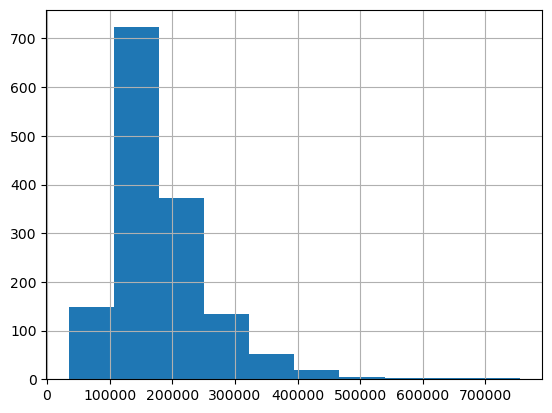

In [13]:
house_df["SalePrice"].hist()

In [20]:
# understand context
print("\n ROws with null SalePrice :")
np.set_printoptions(threshold=np.inf)
print(house_df[house_df["SalePrice"].isnull()][["Id"]].to_numpy().flatten())


 ROws with null SalePrice :
[1460 1461 1462 1463 1464 1465 1466 1467 1468 1469 1470 1471 1472 1473
 1474 1475 1476 1477 1478 1479 1480 1481 1482 1483 1484 1485 1486 1487
 1488 1489 1490 1491 1492 1493 1494 1495 1496 1497 1498 1499 1500 1501
 1502 1503 1504 1505 1506 1507 1508 1509 1510 1511 1512 1513 1514 1515
 1516 1517 1518 1519 1520 1521 1522 1523 1524 1525 1526 1527 1528 1529
 1530 1531 1532 1533 1534 1535 1536 1537 1538 1539 1540 1541 1542 1543
 1544 1545 1546 1547 1548 1549 1550 1551 1552 1553 1554 1555 1556 1557
 1558 1559 1560 1561 1562 1563 1564 1565 1566 1567 1568 1569 1570 1571
 1572 1573 1574 1575 1576 1577 1578 1579 1580 1581 1582 1583 1584 1585
 1586 1587 1588 1589 1590 1591 1592 1593 1594 1595 1596 1597 1598 1599
 1600 1601 1602 1603 1604 1605 1606 1607 1608 1609 1610 1611 1612 1613
 1614 1615 1616 1617 1618 1619 1620 1621 1622 1623 1624 1625 1626 1627
 1628 1629 1630 1631 1632 1633 1634 1635 1636 1637 1638 1639 1640 1641
 1642 1643 1644 1645 1646 1647 1648 1649 1650 16

In [15]:
# # since SalePrice is our target column, we should not fll the null values of the target columns
# # we need to eliminate the rows having SalePrice as null values
# print(f"Original : {len(house_df)} rows")
# house_df = house_df.dropna(subset=["SalePrice"])
# print(f"After removal : {len(house_df)} rows")

Original : 2917 rows
After removal : 1460 rows


In [21]:
df_main = house_df[house_df["SalePrice"].notna()].copy()
df_empty = house_df[house_df["SalePrice"].isna()].copy()

In [22]:
df_main.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [23]:
df_empty.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1460,1460,20,RH,11622,Inside,1Fam,6,1961,1961,VinylSd,144.0,882.0,NaN
1461,1461,20,RL,14267,Corner,1Fam,6,1958,1958,Wd Sdng,0.0,1329.0,NaN
1462,1462,60,RL,13830,Inside,1Fam,5,1997,1998,VinylSd,0.0,928.0,NaN
1463,1463,60,RL,9978,Inside,1Fam,6,1998,1998,VinylSd,0.0,926.0,NaN
1464,1464,120,RL,5005,Inside,TwnhsE,5,1992,1992,HdBoard,0.0,1280.0,NaN


In [33]:
# from sklearn.preprocessing import OneHotEncoder
# ONE = OneHotEncoder()
df = pd.get_dummies(df_main, columns=["BldgType","LotConfig","MSZoning","Exterior1st"],drop_first = True,dtype=int)

In [34]:
df.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,BldgType_2fmCon,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0,...,0,0,0,0,0,0,0,1,0,0


In [35]:
# seperate features(x) and target(y)
x = df.drop("SalePrice",axis=1)
y = df["SalePrice"]

In [36]:
x.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,BldgType_2fmCon,BldgType_Duplex,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [37]:
y.head()

0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: SalePrice, dtype: float64

In [44]:
print(len(y))

1460


In [38]:
from sklearn.model_selection import train_test_split
# split the df ( df_main is this case ) into train and test dataset
# 80% => train , 20% => test
x_train, x_test, y_train,  y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [46]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 2000)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
